In [1]:
import numpy as np

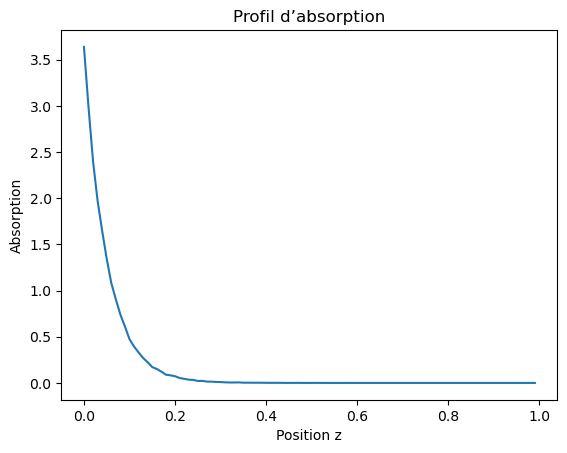

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Wc = 0.01
m = 10
delta_z = 1
dz = 0.01
mu_a = 20
mu_z = 1
N = 100000

z_axis = np.arange(0, delta_z, dz)
absorption = np.zeros(len(z_axis))

rng = np.random.default_rng()

for i in range(N):

    z = 0
    W = 1

    while W > 0 and z < delta_z:

        e_1 = rng.uniform()
        L = -np.log(e_1) / mu_a
        z += mu_z * L

        delta_W = mu_a * W   # absorption locale

        voxel = int(z / dz)

        if voxel < len(absorption):
            absorption[voxel] += delta_W

        W -= delta_W

        if W < Wc:
            if rng.uniform() <= 1/m:
                W *= m
            else:
                W = 0

absorption /= N

plt.plot(z_axis, absorption)
plt.xlabel("Position z")
plt.ylabel("Absorption")
plt.title("Profil d’absorption")
#plt.yscale("log")
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# paramètres
Nphotons = 100000
Wc = 0.01
m = 10

mu_a = 20   # mm^-1

L = 2.0  # mm taille du cube
Nx = Ny = Nz = 100

dx = dy = dz = L / Nx

# volume d'absorption
A = np.zeros((Nx, Ny, Nz))

rng = np.random.default_rng()

for i in range(Nphotons):

    x = Nx // 2
    y = Ny // 2
    z = 0

    W = 1.0

    z_pos = 0.0

    while W > 0 and z_pos < L:

        # distance libre
        s = -np.log(rng.uniform()) / mu_a

        z_pos += s

        iz = int(z_pos / dz)

        if iz >= Nz:
            break

        # absorption locale
        deltaW = mu_a * W 

        A[x, y, iz] += deltaW

        W -= deltaW

        # roulette russe
        if W < Wc:
            if rng.uniform() <= 1/m:
                W *= m
            else:
                W = 0

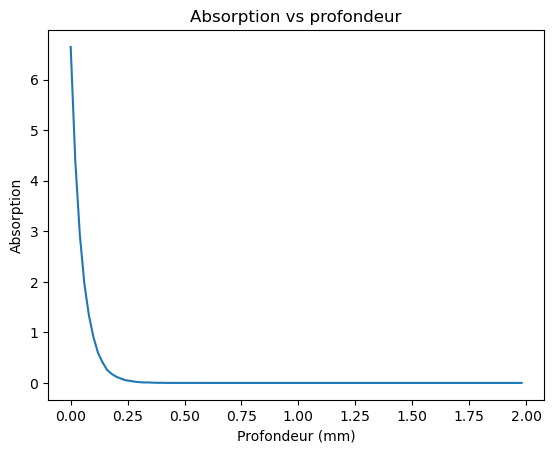

In [4]:
depth_abs = np.sum(A, axis=(0,1)) / Nphotons

z_axis = np.arange(Nz) * dz

plt.figure()
plt.plot(z_axis, depth_abs)
#plt.yscale("log")
plt.xlabel("Profondeur (mm)")
plt.ylabel("Absorption")
plt.title("Absorption vs profondeur")
plt.show()

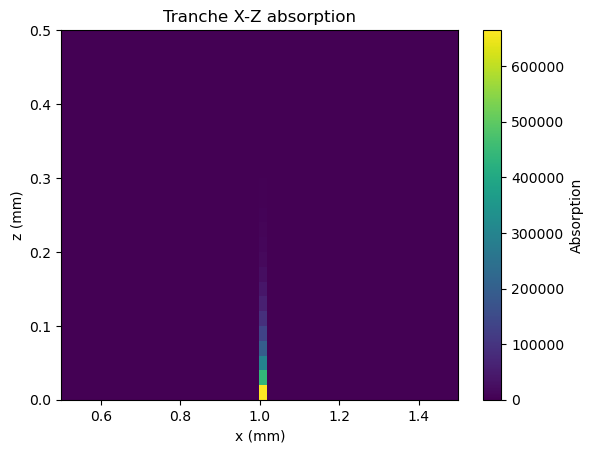

In [5]:
plt.figure()
plt.imshow(A[:, Ny//2, :].T,
           extent=[0, L, L, 0],
           aspect='auto')

plt.xlim(0.5, 1.5)
plt.ylim(0, 0.5) 

plt.xlabel("x (mm)")
plt.ylabel("z (mm)")
plt.title("Tranche X-Z absorption")
plt.colorbar(label="Absorption")
plt.show()

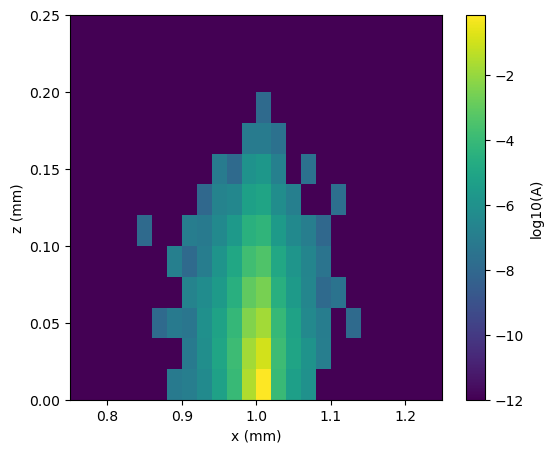

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# PARAMÈTRES PHYSIQUES
# ======================

Nphotons = 1000000
mu_a = 80      # mm^-1 absorption
mu_s = 20    # mm^-1 diffusion
mu_t = mu_a + mu_s
g = 0.9         # anisotropie
Wc = 0.01
m = 10

# ======================
# GÉOMÉTRIE
# ======================

L = 2.0   # mm cube 2x2x2
Nx = Ny = Nz = 100
dx = L/Nx
dy = L/Ny
dz = L/Nz
A = np.zeros((Nx,Ny,Nz))
rng = np.random.default_rng()

# ======================
# SIMULATION MONTE CARLO
# ======================

for p in range(Nphotons):
    # position initiale (centre, surface)
    x = L/2
    y = L/2
    z = 0

    # direction initiale
    mu_x = 0.0
    mu_y = 0.0
    mu_z = 1.0

    W = 1.0

    while True:
        # distance libre
        s = -np.log(rng.uniform(0,1))/mu_t

        # propagation
        x += mu_x*s
        y += mu_y*s
        z += mu_z*s

        # sortir si hors du cube
        if x<0 or x>=L or y<0 or y>=L or z<0 or z>=L:
            break

        # voxel
        ix = int(x/dx)
        iy = int(y/dy)
        iz = int(z/dz)

        # absorption
        deltaW = (mu_a/mu_t)*W
        W -= deltaW

        A[ix,iy,iz] += deltaW

        # roulette russe
        if W < Wc:
            if rng.uniform(0,1) <= 1/m:
                W *= m
            else:
                W=0
                break

        # ======================
        # DIFFUSION HG
        # ======================

        e2 = rng.uniform(0,1)
        e3 = rng.uniform(0,1)

        phi = 2*np.pi*e2

        cos_theta = (1/(2*g))*(1+g**2 -
                        ((1-g**2)/(1-g+2*g*e3))**2)
        
        sin_theta = np.sqrt(1-cos_theta**2)

        if mu_z == 1:
            mu_x = sin_theta*np.cos(phi)
            mu_y = sin_theta*np.sin(phi)
            mu_z = np.sign(mu_z)*cos_theta
        else:
            denom = np.sqrt(1-mu_z**2)
            mu_x_new = (sin_theta*(mu_x*mu_z*np.cos(phi)
                        - mu_y*np.sin(phi))/denom
                        + mu_x*cos_theta)

            mu_y_new = (sin_theta*(mu_y*mu_z*np.cos(phi)
                        + mu_x*np.sin(phi))/denom
                        + mu_y*cos_theta)

            mu_z_new = (-sin_theta*np.cos(phi)*denom
                        + mu_z*cos_theta)

            mu_x,mu_y,mu_z = mu_x_new,mu_y_new,mu_z_new

# normalisation
A /= Nphotons
        

# ======================
# SLICE VISUALISATION
# ======================

slice_mid = A[:,Ny//2,:]

plt.figure(figsize=(6,5))

plt.imshow(np.log10(slice_mid.T + 1e-12),
           extent=[0,L,0,L],
           origin='lower',
           aspect='auto')

plt.xlim(0.75, 1.25)
plt.ylim(0, 0.25) 

plt.xlabel("x (mm)")
plt.ylabel("z (mm)")
#plt.title("Log10 absorbed photons slice")

plt.colorbar(label="log10(A)")

plt.show()


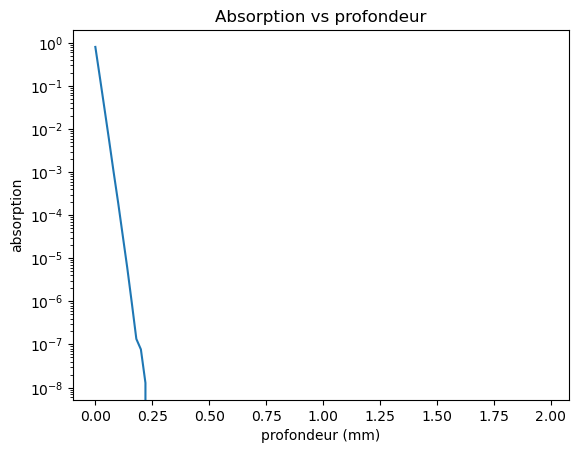

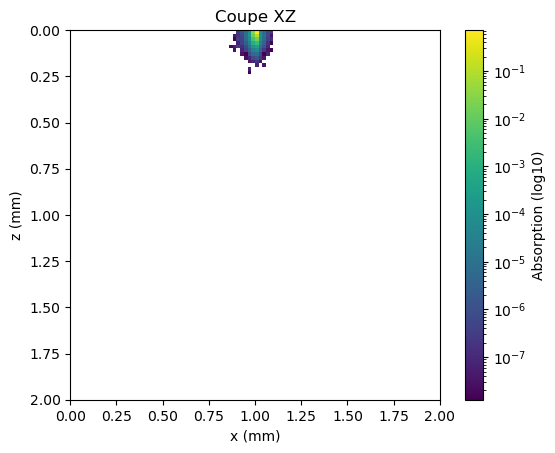

In [7]:
# ======================
# FIGURE 1
# absorption vs profondeur
# ======================

depth = np.sum(A,axis=(0,1))

z_axis = np.arange(Nz)*dz

plt.figure()
plt.plot(z_axis,depth)
plt.xlabel("profondeur (mm)")
plt.ylabel("absorption")
plt.title("Absorption vs profondeur")
plt.yscale("log")
plt.show()


# ======================
# FIGURE 2
# coupe XZ centre
# ======================

from matplotlib.colors import LogNorm

plt.figure()

plt.imshow(A[:,Ny//2,:].T,
           extent=[0,L,L,0],
           norm=LogNorm())

#plt.xlim(0.5, 1.5)
#plt.ylim(0, 0.5) 

plt.xlabel("x (mm)")
plt.ylabel("z (mm)")
plt.title("Coupe XZ")

plt.colorbar(label="Absorption (log10)")
plt.show()
